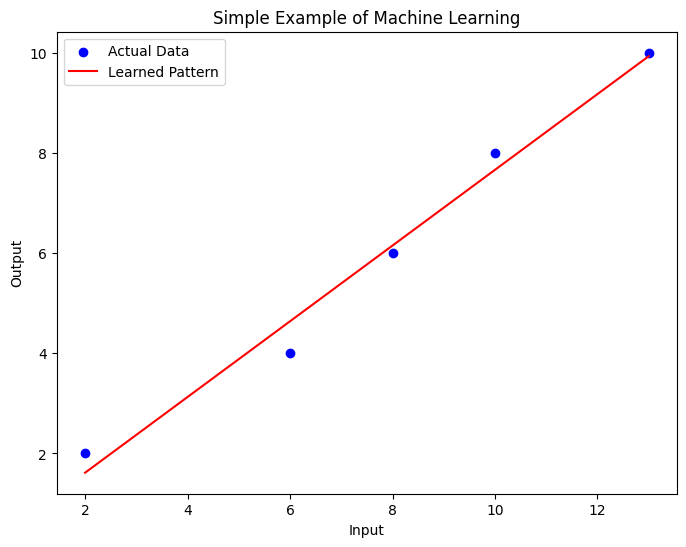


Model learned the pattern: y = 0.7558139534883721 x + 0.10465116279069786
This is a simple example of how ML can learn patterns from data.


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import learning_curve
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

def demonstrate_learning():
    # Generate sample data
    X = np.array([[2], [6], [8], [10], [13]])
    y = np.array([2, 4, 6, 8, 10])

    # Create and fit a simple linear model
    model = LinearRegression()   #y=f(x)
    model.fit(X, y)

    # Make predictions
    predictions = model.predict(X)

    # Visualize the results
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', label='Actual Data')
    plt.plot(X, predictions, color='red', label='Learned Pattern')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('Simple Example of Machine Learning')
    plt.legend()
    plt.show()

    print("\nModel learned the pattern: y =", model.coef_[0], "x +", model.intercept_)
    print("This is a simple example of how ML can learn patterns from data.")

demonstrate_learning()

Estimated coefficients:
b_0 = 1.2363636363636363            
b_1 = 1.1696969696969697


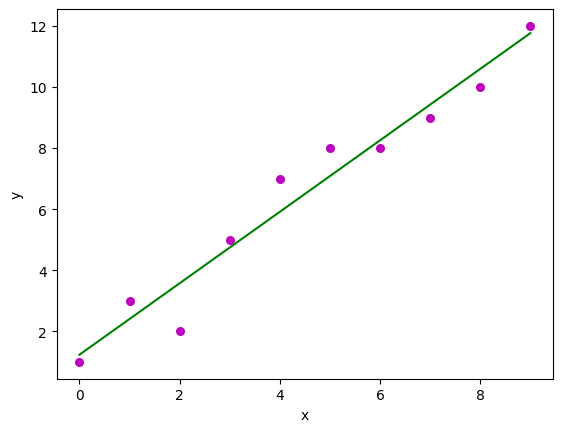

In [2]:
#Linear Regression

import numpy as np
import matplotlib.pyplot as plt

def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

def plot_regression_line(x, y, b):
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = "m",
               marker = "o", s = 30)

    # predicted response vector
    y_pred = b[0] + b[1]*x

    # plotting the regression line
    plt.plot(x, y_pred, color = "g")

    # putting labels
    plt.xlabel('x')
    plt.ylabel('y')

    # function to show plot
    plt.show()

def main():
    # observations / data
    x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])

    # estimating coefficients
    b = estimate_coef(x, y)
    print("Estimated coefficients:\nb_0 = {}  \
          \nb_1 = {}".format(b[0], b[1]))

    # plotting regression line
    plot_regression_line(x, y, b)

if __name__ == "__main__":
    main()

Regression Coefficients are: [ 4.44172372e-01  9.74383293e-03 -1.18605954e-01  7.47844462e-01
  7.08026940e-07 -3.15688733e-03 -4.17156489e-01 -4.30972526e-01]
Variance score is: 0.6065738282380428


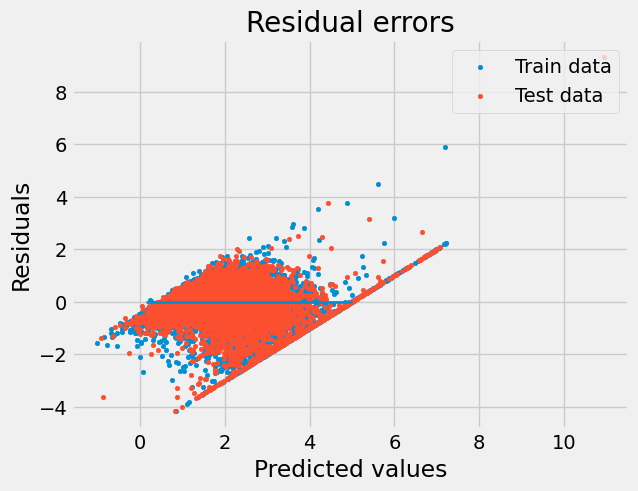

In [4]:
# Multiple Regression

import matplotlib.pyplot as mtpplt
import numpy as nmp
import pandas as pd
from sklearn import linear_model as LM
from sklearn.model_selection import train_test_split as tts

# ---------------- Load California housing dataset (CSV mirror, avoids 403 errors) ----------------

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Recreate the same 8 features used in sklearn's fetch_california_housing
df["AveRooms"]  = df["total_rooms"] / df["households"]
df["AveBedrms"] = df["total_bedrooms"] / df["households"]
df["AveOccup"]  = df["population"] / df["households"]
df = df.dropna()

feature_cols = ["median_income", "housing_median_age", "AveRooms",
                 "AveBedrms", "population", "AveOccup", "latitude", "longitude"]

# Feature matrix and target vector
H = df[feature_cols].values
f = df["median_house_value"].values / 100_000   # scale to match sklearn's target units (100,000s)

# Train-test split
H_train, H_test, f_train, f_test = tts(
    H, f, test_size=0.4, random_state=1
)

# Create linear regression model
reg1 = LM.LinearRegression()

# Train model
reg1.fit(H_train, f_train)

# Print coefficients
print("Regression Coefficients are:", reg1.coef_)

# Variance score (R²)
print("Variance score is:", reg1.score(H_test, f_test))

# ---------------- Residual Plot ----------------

mtpplt.style.use("fivethirtyeight")

# Training residuals
mtpplt.scatter(
    reg1.predict(H_train),
    reg1.predict(H_train) - f_train,
    s=10,
    label="Train data"
)

# Testing residuals
mtpplt.scatter(
    reg1.predict(H_test),
    reg1.predict(H_test) - f_test,
    s=10,
    label="Test data"
)

# Zero residual line
mtpplt.hlines(y=0, xmin=f.min(), xmax=f.max(), linewidth=2)

mtpplt.legend(loc="upper right")
mtpplt.title("Residual errors")
mtpplt.xlabel("Predicted values")
mtpplt.ylabel("Residuals")

mtpplt.show()

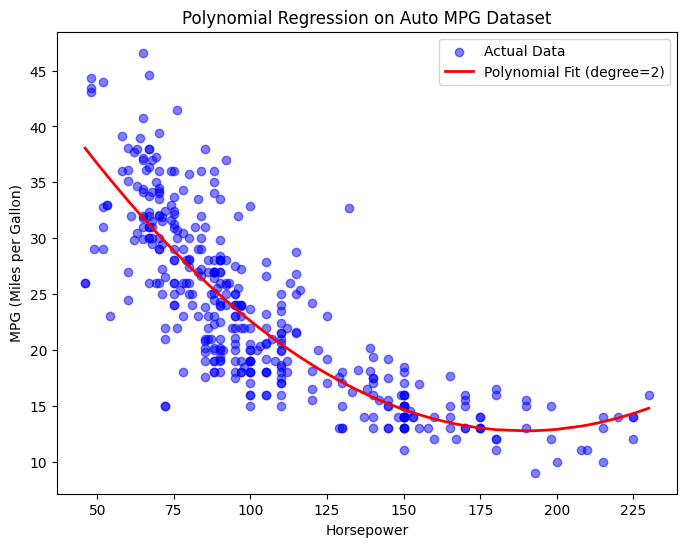

Model R² score: 0.688
This shows how horsepower and MPG follow a curved (non-linear) relationship.


In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

def demonstrate_polynomial_on_real_data():
    # Load a real-life dataset (built into seaborn)
    df = sns.load_dataset('mpg').dropna()

    # Use 'horsepower' to predict 'mpg' (classic non-linear relationship)
    X = df[['horsepower']].values
    y = df['mpg'].values

    # Transform input into polynomial features (degree 2)
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Create and fit a polynomial regression model
    # mpg ≈ a·x² + b·x + c
    model = LinearRegression()
    model.fit(X_poly, y)

    # Make predictions (sorted for a smooth curve)
    X_sorted = np.sort(X, axis=0)
    y_pred = model.predict(poly.transform(X_sorted))

    # Visualize the results
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
    plt.plot(X_sorted, y_pred, color='red', linewidth=2, label='Polynomial Fit (degree=2)')
    plt.xlabel('Horsepower')
    plt.ylabel('MPG (Miles per Gallon)')
    plt.title('Polynomial Regression on Auto MPG Dataset')
    plt.legend()
    plt.show()

    # Evaluate the model
    r2 = r2_score(y, model.predict(X_poly))
    print("Model R² score:", round(r2, 3))
    print("This shows how horsepower and MPG follow a curved (non-linear) relationship.")

demonstrate_polynomial_on_real_data()

Customer Dataset (Annual Income, Spending Score):

Customer 1: Income = -9.39, Spending = 6.30
Customer 2: Income = -9.87, Spending = 6.86
Customer 3: Income = -1.52, Spending = 7.55
Customer 4: Income = -7.14, Spending = -5.56
Customer 5: Income = -11.28, Spending = 6.11
Customer 6: Income = -5.85, Spending = -7.07
Customer 7: Income = 4.85, Spending = 2.44
Customer 8: Income = -6.38, Spending = -7.56
Customer 9: Income = -3.08, Spending = 8.79
Customer 10: Income = 3.21, Spending = 2.76
Customer 11: Income = -3.23, Spending = 11.24
Customer 12: Income = 5.07, Spending = 1.14
Customer 13: Income = -2.26, Spending = 6.66
Customer 14: Income = -4.21, Spending = 8.51
Customer 15: Income = -9.62, Spending = 6.74
Customer 16: Income = -3.35, Spending = 8.62
Customer 17: Income = -10.79, Spending = 7.38
Customer 18: Income = 2.21, Spending = 2.20
Customer 19: Income = -2.39, Spending = 10.18
Customer 20: Income = -1.80, Spending = 11.64
Customer 21: Income = 6.03, Spending = 0.99
Customer 2

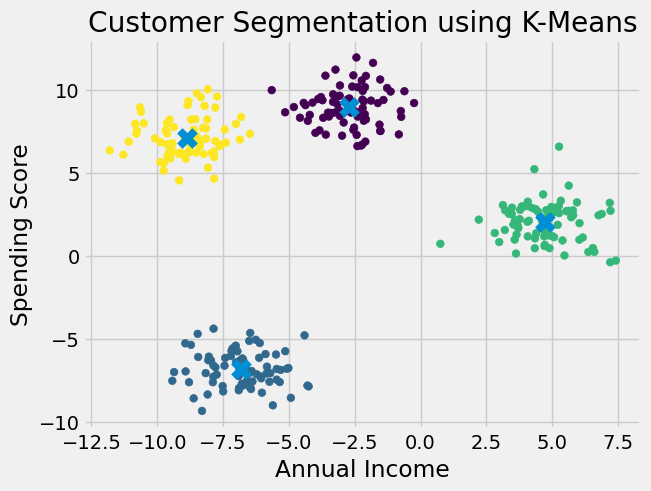

In [ ]:
# Customer Segmentation (K-Means)

# | Segment                     | Meaning                 |
# | --------------------------- | ----------------------- |
# | High income + High spending | Premium / VIP customers |
# | High income + Low spending  | Potential targets       |
# | Low income + High spending  | Discount-driven buyers  |
# | Low income + Low spending   | Low priority            |

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate sample customer data
# Feature 1: Annual Income
# Feature 2: Spending Score
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

print("Customer Dataset (Annual Income, Spending Score):\n")
for i, customer in enumerate(X):
    print(f"Customer {i+1}: Income = {customer[0]:.2f}, Spending = {customer[1]:.2f}")

# 2. Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 3. Plot customer segments
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()
